In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

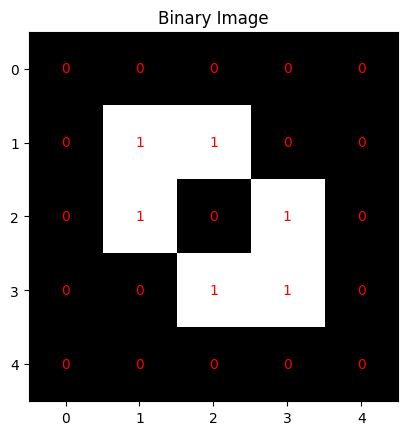

In [ ]:
binary = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0]
])

plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
for i in range(5):
    for j in range(5):
        plt.text(j, i, str(binary[i,j]), ha='center', va='center', color='red')
plt.show()

 4-Neighbour Connectivity

In [ ]:
def get_4_neighbors(img, r, c):
    neighbors = []
    rows, cols = img.shape
    for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
        nr, nc = r+dr, c+dc
        if 0 <= nr < rows and 0 <= nc < cols and img[nr,nc]==1:
            neighbors.append((nr,nc))
    return neighbors

print("Pixel (2,1):", binary[2,1])
print("4-neighbors:", get_4_neighbors(binary, 2, 1))

Pixel (2,1): 1
4-neighbors: [(1, 1)]


 8-Neighbour Connectivity

In [ ]:
def get_8_neighbors(img, r, c):
    neighbors = []
    rows, cols = img.shape
    for dr in [-1,0,1]:
        for dc in [-1,0,1]:
            if dr==0 and dc==0: continue
            nr, nc = r+dr, c+dc
            if 0 <= nr < rows and 0 <= nc < cols and img[nr,nc]==1:
                neighbors.append((nr,nc))
    return neighbors

print("Pixel (2,1):", binary[2,1])
print("8-neighbors:", get_8_neighbors(binary, 2, 1))

Pixel (2,1): 1
8-neighbors: [(1, 1), (1, 2), (3, 2)]


m-Connectivity

In [ ]:
def get_m_neighbors(img, r, c):
    m_conn = get_4_neighbors(img, r, c) # start with 4
    rows, cols = img.shape
    for dr, dc in [(-1,-1), (-1,1), (1,-1), (1,1)]:
        nr, nc = r+dr, c+dc
        if 0 <= nr < rows and 0 <= nc < cols and img[nr,nc]==1:
            # if both 4-path pixels are 1, don't include diagonal
            if not (img[r+dr, c]==1 and img[r, c+dc]==1):
                m_conn.append((nr,nc))
    return m_conn

print("m-connectivity for (2,1):", get_m_neighbors(binary, 2, 1))

m-connectivity for (2,1): [(1, 1), (1, 2), (3, 2)]


Euclidean Distance

In [ ]:
p = np.array([1,1])
q = np.array([3,3])
D_e = np.sqrt((p[0]-q[0])**2 + (p[1]-q[1])**2)
print("Euclidean Distance",D_e)

Euclidean Distance 2.8284271247461903


City-block Distance

In [ ]:
p = np.array([1,1])
q = np.array([3,3])
D_4 = abs(p[0]-q[0]) + abs(p[1]-q[1])
print("City-block D4 =",D_4)

City-block D4 = 4


 Chessboard Distance

In [ ]:
p = np.array([1,1])
q = np.array([3,3])
D_8 = max(abs(p[0]-q[0]), abs(p[1]-q[1]))
print("Chessboard D8 =",D_8)

Chessboard D8 = 2


Q2 - DFT & DCT

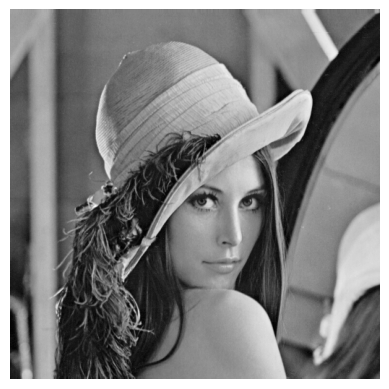

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("Lenna_(test_image).png", 0)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

Calculate 2-D DFT

In [ ]:
dft = np.fft.fft2(img)
print("DFT calculated")
print("DFT shape:", dft.shape)

DFT calculated
DFT shape: (512, 512)


Shift Zero-frequency to Center

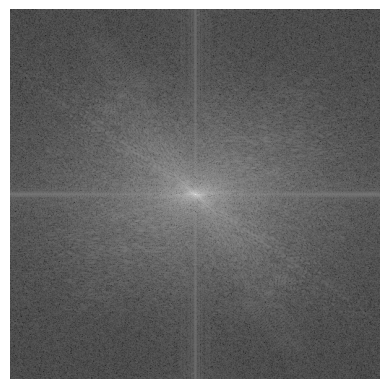

In [ ]:
dft_shift = np.fft.fftshift(dft)
plt.imshow(np.log(1 + np.abs(dft_shift)), cmap='gray')
plt.axis('off')
plt.show()

Magnitude Spectrum

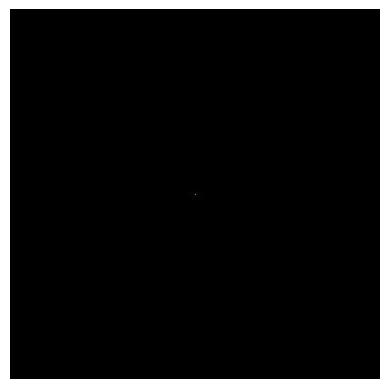

In [ ]:
magnitude = np.abs(dft_shift)
plt.imshow(magnitude, cmap='gray')
plt.axis('off')
plt.show()

 Logarithmic Scaling

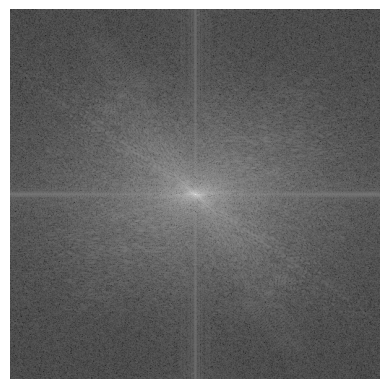

In [ ]:
magnitude_log = 20 * np.log(1 + magnitude)
plt.imshow(magnitude_log, cmap='gray')
plt.axis('off')
plt.show()

Calculate 2-D DCT

In [ ]:
img_float = np.float32(img)
dct = cv2.dct(img_float)
print("DCT calculated")
print("DCT shape:", dct.shape)
print("Top-left 8x8 low freq:")
print(dct[:8,:8].astype(int))

DCT calculated
DCT shape: (512, 512)
Top-left 8x8 low freq:
[[67802 -4509 -1224  4868  4163 -2207  -730  1855]
 [ 3746  4035 -2709 -1252 -1715  1468   905  -906]
 [   62  1193 -3032  3646 -2639  4795    84  -565]
 [ -659  -976  3437 -2480   804  1596 -3203  1395]
 [-1034   969   853  1130  -104   601  -336   616]
 [ -237  -276  2473    98 -2108  -757  1623  2565]
 [ 1400  -899  1070 -1152  -532   142  1832 -1745]
 [ 1620 -1278  -785   998   -78   538   564 -1512]]


 Display DCT Coefficient Matrix

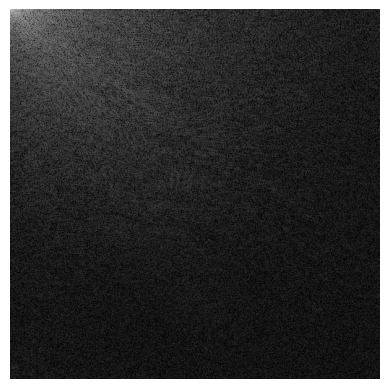

In [ ]:
plt.imshow(np.log(1 + np.abs(dct)), cmap='gray')
plt.axis('off')
plt.show()